In [1]:
from sklearn.datasets import load_diabetes

In [2]:
dataset=load_diabetes()

In [3]:
dataset

{'data': array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
          0.01990749, -0.01764613],
        [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
         -0.06833155, -0.09220405],
        [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
          0.00286131, -0.02593034],
        ...,
        [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
         -0.04688253,  0.01549073],
        [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
          0.04452873, -0.02593034],
        [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
         -0.00422151,  0.00306441]], shape=(442, 10)),
 'target': array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
         69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
         68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
         87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
        259.,  53., 190., 142.,  75., 142.

In [4]:
import pandas as pd
df_diabetes=pd.DataFrame(dataset.data,columns=['age',
        'sex','bmi','bp','s1'
        ,'s2','s3','s4','s5','s6'])


In [5]:
df_diabetes.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [6]:
X=df_diabetes
y=dataset['target']
from sklearn.model_selection import train_test_split

In [7]:
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.3)

In [8]:
X_train.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
225,0.030811,0.050680,0.032595,0.049415,-0.040096,-0.043589,-0.069172,0.034309,0.063015,0.003064
412,0.074401,-0.044642,0.085408,0.063187,0.014942,0.013091,0.015505,-0.002592,0.006207,0.085907
118,-0.056370,0.050680,-0.010517,0.025315,0.023198,0.040022,-0.039719,0.034309,0.020609,0.056912
114,0.023546,-0.044642,0.110198,0.063187,0.013567,-0.032942,-0.024993,0.020655,0.099241,0.023775
364,0.001751,0.050680,-0.006206,-0.019442,-0.009825,0.004949,-0.039719,0.034309,0.014821,0.098333


In [9]:
X_train.corr

<bound method DataFrame.corr of           age       sex       bmi        bp        s1        s2        s3  \
225  0.030811  0.050680  0.032595  0.049415 -0.040096 -0.043589 -0.069172   
412  0.074401 -0.044642  0.085408  0.063187  0.014942  0.013091  0.015505   
118 -0.056370  0.050680 -0.010517  0.025315  0.023198  0.040022 -0.039719   
114  0.023546 -0.044642  0.110198  0.063187  0.013567 -0.032942 -0.024993   
364  0.001751  0.050680 -0.006206 -0.019442 -0.009825  0.004949 -0.039719   
..        ...       ...       ...       ...       ...       ...       ...   
106 -0.096328 -0.044642 -0.076264 -0.043542 -0.045599 -0.034821  0.008142   
270  0.005383  0.050680  0.030440  0.083844 -0.037344 -0.047347  0.015505   
348  0.030811 -0.044642 -0.020218 -0.005670 -0.004321 -0.029497  0.078093   
435 -0.012780 -0.044642 -0.023451 -0.040099 -0.016704  0.004636 -0.017629   
102 -0.092695 -0.044642  0.028284 -0.015999  0.036958  0.024991  0.056003   

           s4        s5        s6  
225  0.

<Axes: >

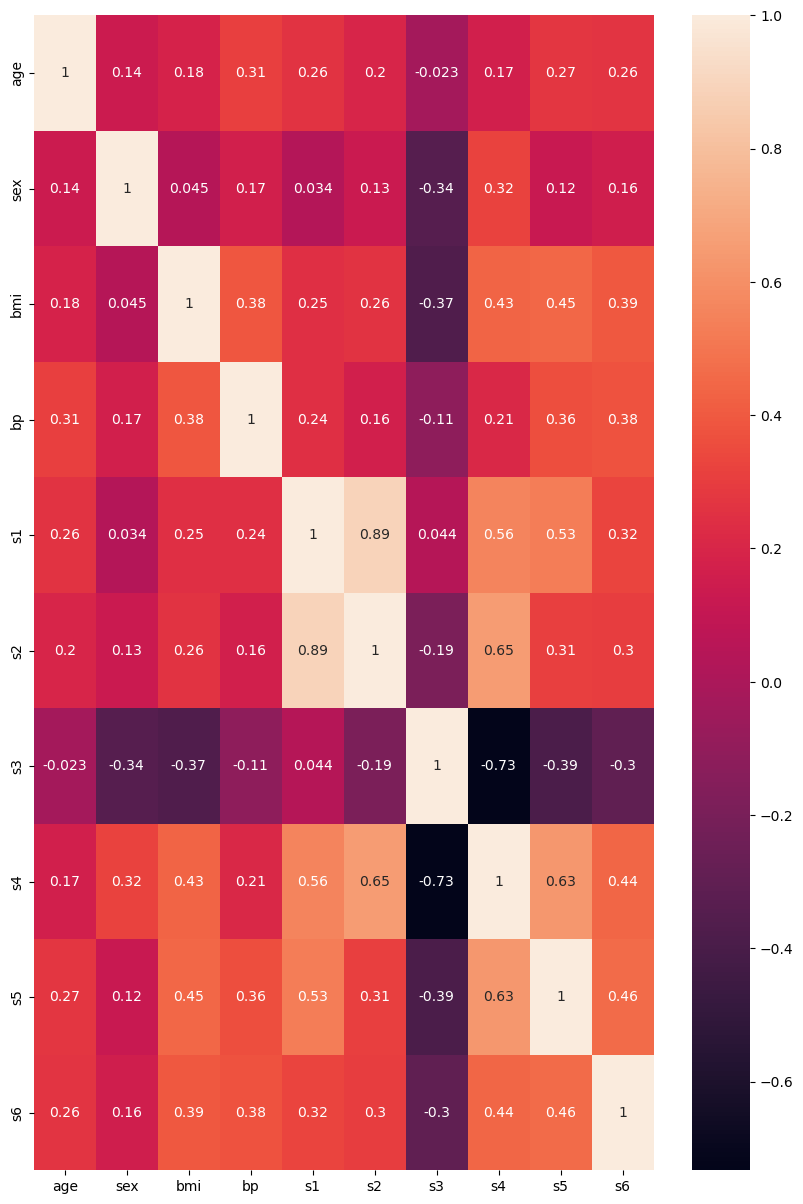

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,15))
sns.heatmap(X_train.corr(),annot=True)

In [12]:
from sklearn.tree import DecisionTreeRegressor
regressor=DecisionTreeRegressor()
regressor.fit(X_train,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [13]:
param={
    'criterion':['squared_error','friedman_mse','absolute_error','poisson'],
    'splitter':['best','random'],
    'max_depth':[1,2,3,4,5,10,15,20,25],
    'max_features':['auto','sqrt','log2'],
}

In [14]:
from sklearn.model_selection import GridSearchCV
grid_search=GridSearchCV(estimator=regressor,param_grid=param,cv=5,scoring='neg_mean_squared_error',n_jobs=-1,verbose=2)

In [16]:
import warnings
warnings.filterwarnings('ignore')
grid_search.fit(X_train,y_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


,estimator,DecisionTreeRegressor()
,param_grid,"{'criterion': ['squared_error', 'friedman_mse', ...], 'max_depth': [1, 2, ...], 'max_features': ['auto', 'sqrt', ...], 'splitter': ['best', 'random']}"
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'friedman_mse'


In [18]:
grid_search.best_params_

{'criterion': 'friedman_mse',
 'max_depth': 2,
 'max_features': 'log2',
 'splitter': 'best'}

In [19]:
y_pred=grid_search.predict(X_test)

In [20]:
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
print('Mean Squared Error:',mse)
print('R2 Score:',r2)
print('Mean Absolute Error:',mae)


Mean Squared Error: 3673.520795083102
R2 Score: 0.3195051195451398
Mean Absolute Error: 49.79965839593086


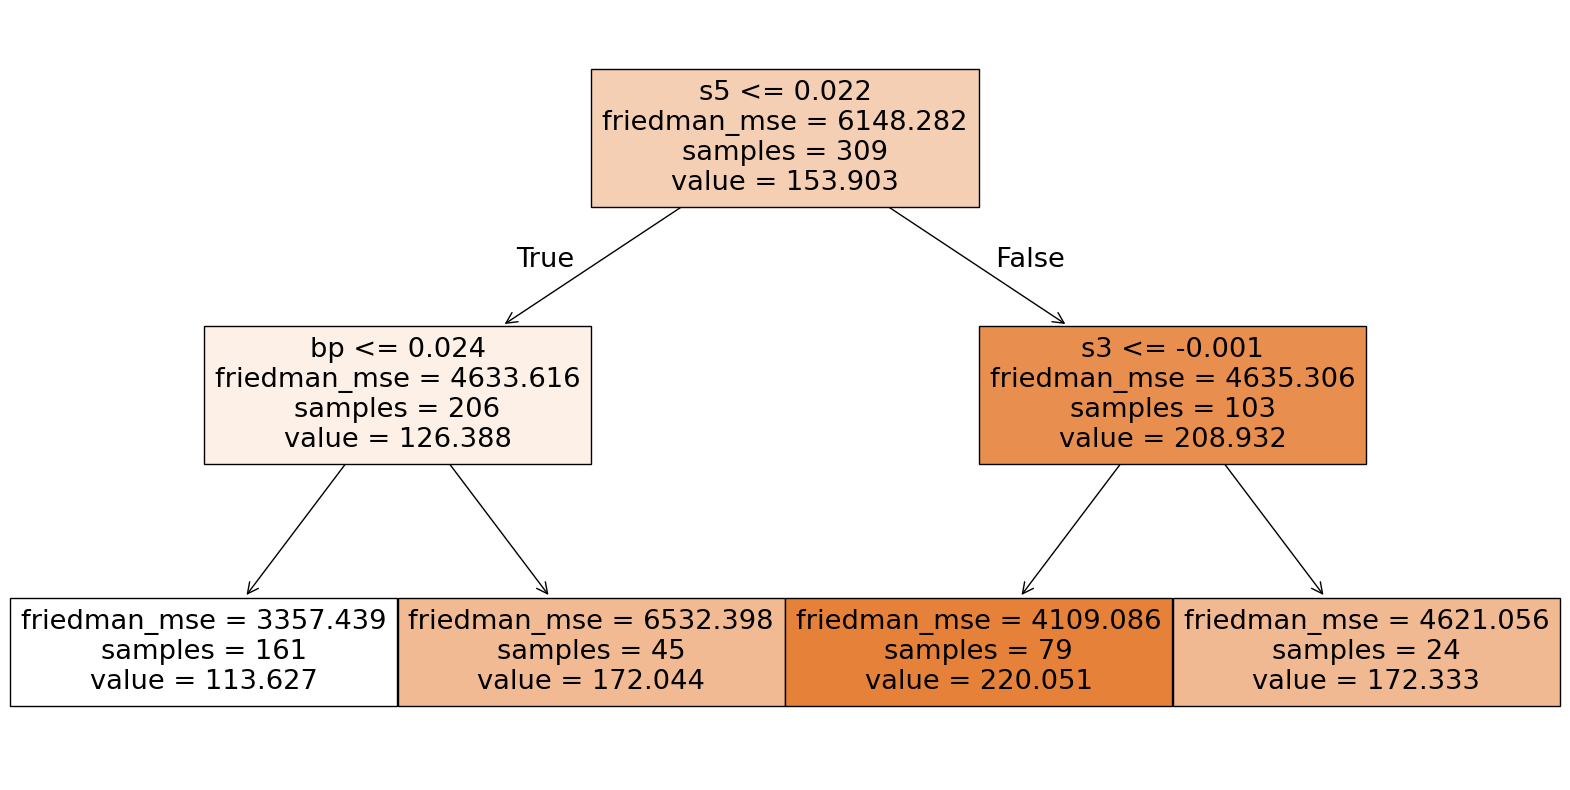

In [22]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree  
plt.figure(figsize=(20,10))
plot_tree(grid_search.best_estimator_,filled=True,feature_names=X.columns)
plt.show()